# **4 Analysis of the data**

On top of the selected dataset, you must develop different analytics. In this section, the usage
of the Dataframe API is mandatory. In addition to the materials at ALUD, you could need to
check the following links:

● Spark SQL, DataFrames and Datasets Guide:
https://spark.apache.org/docs/latest/sql-programming-guide.html

● Spark SQL API Reference:
https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/index.html
Spark SQL API includes a wide set of functions that could be useful to achieve your goals at this
section. It would be nice if you take a look before starting coding anything:

● Functions:
https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/functions.html
All the analytics must be launched in the computation cluster you have deployed in section 3.

The source code implementing the analytics could be in a single or multiple *.py files. The
results must be saved in HDFS. Later, you must use the proper tool (Colab, JupyterLab,
Zeppelin…) to present the results.

If you select a dataset from sources like Kaggle, you must avoid implementing any analytics
already done by the community



## Dataset Loading - In pure Python

In [ ]:
import pandas as pd

dataset_path = 'file:///home/ec2-user/fatal-police-shootings-data.csv'

dataset = pd.read_csv(dataset_path)

In [ ]:
dataset.head(5)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [ ]:
dataset["manner_of_death"].unique()

array(['shot', 'shot and Tasered'], dtype=object)

## Spark Initialization

In [ ]:
# !pip install pyspark findspark

In [ ]:
import findspark
findspark.init()

import pyspark
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("TGVD Project").getOrCreate()

In [ ]:
dataset = spark.read.csv(dataset_path, header=True, inferSchema=True)

In [ ]:
dataset.printSchema()

root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- date: date (nullable = true)
 |-- manner_of_death: string (nullable = true)
 |-- armed: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- race: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- signs_of_mental_illness: boolean (nullable = true)
 |-- threat_level: string (nullable = true)
 |-- flee: string (nullable = true)
 |-- body_camera: boolean (nullable = true)



Ya tenemos el dataset importado en spark aquí

In [ ]:
dataset.show(5, truncate=False)

+---+------------------+----------+----------------+----------+---+------+----+-------------+-----+-----------------------+------------+-----------+-----------+
|id |name              |date      |manner_of_death |armed     |age|gender|race|city         |state|signs_of_mental_illness|threat_level|flee       |body_camera|
+---+------------------+----------+----------------+----------+---+------+----+-------------+-----+-----------------------+------------+-----------+-----------+
|3  |Tim Elliot        |2015-01-02|shot            |gun       |53 |M     |A   |Shelton      |WA   |true                   |attack      |Not fleeing|false      |
|4  |Lewis Lee Lembke  |2015-01-02|shot            |gun       |47 |M     |W   |Aloha        |OR   |false                  |attack      |Not fleeing|false      |
|5  |John Paul Quintero|2015-01-03|shot and Tasered|unarmed   |23 |M     |H   |Wichita      |KS   |false                  |other       |Not fleeing|false      |
|8  |Matthew Hoffman   |2015-01-04

## 4.1 Analytical questions

1. Does the presence of a body camera have an impact on the likelihood of a fatal shooting?



In [ ]:
from pyspark.sql.functions import round, sum as _sum
from pyspark.sql.functions import col

# Group by body_camera and count
body_camera_impact = dataset.groupBy("body_camera").count()

# Get total count for normalization
total = dataset.count()

# Add percentage column
body_camera_impact_with_percent = body_camera_impact.withColumn(
    "percentage", round((col("count") / total) * 100, 2)
)

# Show the results
body_camera_impact_with_percent.show()


+-----------+-----+----------+
|body_camera|count|percentage|
+-----------+-----+----------+
|       true|  599|     11.22|
|      false| 4739|     88.78|
+-----------+-----+----------+



This result indicates that in 11.22% of fatal cases, the officers were wearing body cameras while in 88.78% of cases they were not wearing any. However, this does not mean that body cameras reduce fatal shootings. The dataset does not contain information about non-fatal shootings, so we cannot calculate if there is a significant difference. Let's try to collect some more insights of the use of body cameras.



In [ ]:
from pyspark.sql.functions import collect_set, size

# Aggregate weapon types per body_camera status
weapon_sets = dataset.groupBy("body_camera").agg(
    collect_set("armed").alias("weapons_used")
)

# Count number of unique weapon types
weapon_variety = weapon_sets.withColumn(
    "weapon_variety", size("weapons_used")
).select("body_camera", "weapon_variety")

# Show result
weapon_variety.show()

+-----------+--------------+
|body_camera|weapon_variety|
+-----------+--------------+
|       true|            36|
|      false|            89|
+-----------+--------------+



These results could indicate that encounters without body cameras tend to involve a broader and more unpredictable range of weapons. While this does not imply that the use of body cameras reduces the severity of the incidents, it could promote a change in the behavior of either officers or civilians when they know they're being recorded.

2. Are certain cities or states overrepresented?

In [ ]:
from pyspark.sql.functions import desc

# Count number of incidents per state
state_counts = dataset.groupBy("state").count().orderBy(desc("count"))
state_counts.show(10, truncate=False)

# Count number of incidents per city
city_counts = dataset.groupBy("city").count().orderBy(desc("count"))
city_counts.show(10, truncate=False)

+-----+-----+
|state|count|
+-----+-----+
|CA   |784  |
|TX   |476  |
|FL   |344  |
|AZ   |251  |
|CO   |191  |
|GA   |180  |
|OK   |161  |
|NC   |155  |
|OH   |154  |
|WA   |152  |
+-----+-----+
only showing top 10 rows

+------------+-----+
|city        |count|
+------------+-----+
|Los Angeles |83   |
|Phoenix     |75   |
|Houston     |56   |
|Las Vegas   |44   |
|San Antonio |43   |
|Columbus    |38   |
|Chicago     |38   |
|Albuquerque |35   |
|Kansas City |33   |
|Jacksonville|33   |
+------------+-----+
only showing top 10 rows



It appears that certain states have more incidents, but without the population size it's not definitive overrepresentation—just higher counts. We will calculate the number of fatal shootings by the population of each state in 2020.

In [ ]:
from pyspark.sql.functions import col, round, year

# Create population DataFrame
population_data = [
    ("AL", 5033094), ("AK", 733017), ("AZ", 7187135), ("AR", 3014546), ("CA", 39521958),
    ("CO", 5787129), ("CT", 3579918), ("DE", 991928), ("DC", 670917), ("FL", 21592035),
    ("GA", 10732888), ("HI", 1451252), ("ID", 1849415), ("IL", 12799088), ("IN", 6790497),
    ("IA", 3191141), ("KS", 2938172), ("KY", 4508318), ("LA", 4652301), ("ME", 1364571),
    ("MD", 6177935), ("MA", 6994598), ("MI", 10072703), ("MN", 5710735), ("MS", 2958536),
    ("MO", 6154744), ("MT", 1087230), ("NE", 1963387), ("NV", 3116967), ("NH", 1378756),
    ("NJ", 9272794), ("NM", 2118606), ("NY", 20105171), ("NC", 10449652), ("ND", 779563),
    ("OH", 11798905), ("OK", 3965415), ("OR", 4243779), ("PA", 12996143), ("RI", 1096530),
    ("SC", 5132249), ("SD", 887948), ("TN", 6927904), ("TX", 29239570), ("UT", 3284077),
    ("VT", 642977), ("VA", 8637615), ("WA", 7727209), ("WV", 1791646), ("WI", 5897375), ("WY", 577681)
]

columns = ["state", "population_2020"]
population_df = spark.createDataFrame(population_data, columns)

# Filter dataset for 2020 incidents only
dataset_2020 = dataset.filter(year("date") == 2020)

# Count incidents by state for 2020 only
state_counts_2020 = dataset_2020.groupBy("state").count()

# Join with population data and compute per-capita rate
joined_df_2020 = state_counts_2020.join(population_df, on="state")
result_df = joined_df_2020.withColumn(
    "incidents_per_100k", round((col("count") / col("population_2020")) * 100000, 2)
).orderBy(desc("incidents_per_100k"))


# Show top 10 overrepresented states
result_df.show(10, truncate=False)

+-----+-----+---------------+------------------+
|state|count|population_2020|incidents_per_100k|
+-----+-----+---------------+------------------+
|AK   |6    |733017         |0.82              |
|NV   |12   |3116967        |0.38              |
|CO   |20   |5787129        |0.35              |
|MT   |3    |1087230        |0.28              |
|ND   |2    |779563         |0.26              |
|AZ   |18   |7187135        |0.25              |
|OK   |9    |3965415        |0.23              |
|MO   |14   |6154744        |0.23              |
|AL   |11   |5033094        |0.22              |
|ME   |3    |1364571        |0.22              |
+-----+-----+---------------+------------------+
only showing top 10 rows



After calculating the number of incidents per capita, some smaller states appear overrepresented in fatal police shootings. Alaska, for example, had the highest rate at 0.82 incidents per 100,000 people, despite having a low number of total incidents. Other less-populated states like Nevada and Montana also ranked high per capita.

3. Do fatal shootings involving mental health crises differ by region or race?

In [ ]:
# Filter dataset for incidents with mental health crisis
mental_health_crisis_df = dataset.filter(dataset.signs_of_mental_illness == 'true')

# Group by state
mental_health_by_state = mental_health_crisis_df.groupBy("state").count().orderBy("count", ascending=False)
mental_health_by_state.show(truncate=False)

# Group by race
mental_health_by_race = mental_health_crisis_df.groupBy("race").count().orderBy("count", ascending=False)
mental_health_by_race.show(truncate=False)

+-----+-----+
|state|count|
+-----+-----+
|CA   |174  |
|FL   |93   |
|TX   |88   |
|WA   |52   |
|AZ   |47   |
|OH   |38   |
|GA   |37   |
|NY   |36   |
|OK   |36   |
|TN   |34   |
|NC   |33   |
|OR   |27   |
|PA   |27   |
|NV   |26   |
|AL   |26   |
|VA   |25   |
|IN   |25   |
|MI   |24   |
|WI   |24   |
|LA   |23   |
+-----+-----+
only showing top 20 rows

+----+-----+
|race|count|
+----+-----+
|W   |692  |
|B   |183  |
|H   |155  |
|NULL|119  |
|A   |23   |
|N   |13   |
|O   |10   |
+----+-----+



We can see that California has the highest number of incidents involving mental health (174), followed by Florida (93) and Texas (88), which is consistent with their large populations.
Racially, White individuals (W) are the most represented group in these incidents (692 cases), followed by Black (B) and Hispanic (H) individuals.

In [ ]:
from pyspark.sql.functions import collect_set, size

mental_health_races_by_state = mental_health_crisis_df.groupBy("state") \
    .agg(
        collect_set("race").alias("races_involved")
    ) \
    .withColumn("distinct_race_count", size("races_involved")) \
    .orderBy("distinct_race_count", ascending=False)

mental_health_races_by_state.show(truncate=False)

+-----+------------------+-------------------+
|state|races_involved    |distinct_race_count|
+-----+------------------+-------------------+
|CA   |[N, H, B, W, A, O]|6                  |
|MN   |[H, B, W, A, O]   |5                  |
|CO   |[N, H, B, W, A]   |5                  |
|WA   |[N, H, B, A, W]   |5                  |
|OK   |[N, H, B, W, A]   |5                  |
|AZ   |[N, H, B, W]      |4                  |
|SC   |[H, B, W, A]      |4                  |
|NV   |[H, B, W, A]      |4                  |
|NC   |[H, B, W, A]      |4                  |
|OH   |[B, W, A, O]      |4                  |
|TN   |[B, W, A, O]      |4                  |
|TX   |[H, B, W, O]      |4                  |
|GA   |[H, B, W, A]      |4                  |
|FL   |[H, B, W, O]      |4                  |
|UT   |[N, H, B, W]      |4                  |
|LA   |[H, B, W]         |3                  |
|IN   |[H, B, W]         |3                  |
|MD   |[H, B, W]         |3                  |
|WY   |[N, H,

These results show that California stands out with the highest racial diversity (6 distinct racial groups) in fatal police shootings involving mental health crises. States like Minnesota, Colorado, Washington, and Oklahoma follow with five groups each, suggesting a broader racial impact in these regions. This diversity may reflect demographic variation or differences in how mental health incidents involving various racial groups are handled across states. The presence of multiple racial groups in such cases highlights the importance of intersectional approaches to both mental health care and policing policies.

4. Is there any seasonal or monthly pattern to the number of fatal shootings?

In [ ]:
from pyspark.sql.functions import month, col, when, year

# Extract month from the 'date' column
dataset = dataset.withColumn("month", month(col("date")))

# Group by month and count the number of fatal shootings
monthly_counts = dataset.groupBy("month").count().orderBy("month")
monthly_counts.show()

# Group by seasons
dataset = dataset.withColumn(
    "season",
    when(col("month").isin([3, 4, 5]), "Spring")
    .when(col("month").isin([6, 7, 8]), "Summer")
    .when(col("month").isin([9, 10, 11]), "Fall")
    .otherwise("Winter")
)

# Group by season and count the number of fatal shootings
seasonal_counts = dataset.groupBy("season").count().orderBy("season")
seasonal_counts.show()

# Extract year from the 'date' column
dataset = dataset.withColumn("year", year(col("date")))

# Group by year and count the number of fatal shootings
yearly_counts = dataset.groupBy("year").count().orderBy("year")
yearly_counts.show()

+-----+-----+
|month|count|
+-----+-----+
|    1|  531|
|    2|  495|
|    3|  552|
|    4|  468|
|    5|  438|
|    6|  408|
|    7|  439|
|    8|  418|
|    9|  363|
|   10|  411|
|   11|  392|
|   12|  423|
+-----+-----+

+------+-----+
|season|count|
+------+-----+
|  Fall| 1166|
|Spring| 1458|
|Summer| 1265|
|Winter| 1449|
+------+-----+

+----+-----+
|year|count|
+----+-----+
|2015|  994|
|2016|  962|
|2017|  986|
|2018|  992|
|2019| 1004|
|2020|  400|
+----+-----+



The analysis shows a slight seasonal variation in fatal shootings, with Spring (1,458 cases) and Winter (1,449 cases) having the highest counts, followed by Summer (1,265) and Fall (1,166). Monthly data reveals a peak in March (552) and a dip in September (363). While these differences are not extreme, they suggest some fluctuations throughout the year. Additionally, the sharp drop in 2020 (400 cases) likely reflects the impact of the COVID-19 pandemic on police activity and public behavior.

5. What percentage of fatal shootings involve (un)armed individuals?

In [ ]:
from pyspark.sql.functions import when, col, count

dataset_with_status = dataset.withColumn(
    "armed_status",
    when((col("armed").isNull()) | (col("armed") == "unarmed"), "Unarmed").otherwise("Armed")
)

armed_counts = dataset_with_status.groupBy("armed_status").agg(count("*").alias("count"))

total_shootings = dataset_with_status.count()

armed_percentages = armed_counts.withColumn(
    "percentage", (col("count") / total_shootings) * 100
)

armed_percentages.show(truncate=False)


+------------+-----+------------------+
|armed_status|count|percentage        |
+------------+-----+------------------+
|Unarmed     |558  |10.453353315848632|
|Armed       |4780 |89.54664668415137 |
+------------+-----+------------------+



6. What are the racial distributions of victims in fatal police shootings in different states?

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql import functions as F

grouped = dataset.groupBy("state", "race").count()

pivoted = grouped.groupBy("state").pivot("race").agg(F.first("count")).fillna(0)

pivoted.orderBy("state").show(truncate=False)


#W = White, B = Black, H = Hispanic, A = Asian, N = Native American, O = Other, NaN = Unknown or not recorde

+-----+----+---+---+---+---+---+---+
|state|null|A  |B  |H  |N  |O  |W  |
+-----+----+---+---+---+---+---+---+
|AK   |4   |2  |3  |0  |9  |0  |21 |
|AL   |9   |0  |29 |1  |0  |0  |63 |
|AR   |11  |1  |25 |0  |0  |0  |43 |
|AZ   |33  |0  |16 |82 |13 |0  |107|
|CA   |107 |28 |119|306|4  |9  |211|
|CO   |33  |5  |17 |46 |4  |2  |84 |
|CT   |1   |0  |3  |6  |0  |0  |11 |
|DC   |0   |0  |12 |0  |0  |0  |1  |
|DE   |3   |0  |5  |0  |0  |0  |5  |
|FL   |29  |1  |106|51 |0  |4  |153|
|GA   |30  |4  |67 |8  |0  |0  |71 |
|HI   |1   |9  |1  |1  |0  |15 |3  |
|IA   |1   |0  |7  |0  |0  |0  |24 |
|ID   |4   |0  |1  |5  |1  |0  |30 |
|IL   |5   |0  |57 |13 |0  |0  |28 |
|IN   |6   |0  |28 |4  |0  |0  |56 |
|KS   |2   |0  |6  |8  |1  |0  |31 |
|KY   |8   |1  |14 |3  |1  |0  |66 |
|LA   |10  |2  |57 |1  |0  |0  |37 |
|MA   |3   |0  |8  |7  |0  |1  |16 |
+-----+----+---+---+---+---+---+---+
only showing top 20 rows



7. What is the trend in the number of fatal shootings per year? Is the number increasing or decreasing?

   year  count  change
0  2015    994     0.0
1  2016    962   -32.0
2  2017    986    24.0
3  2018    992     6.0
4  2019   1004    12.0
5  2020    400  -604.0


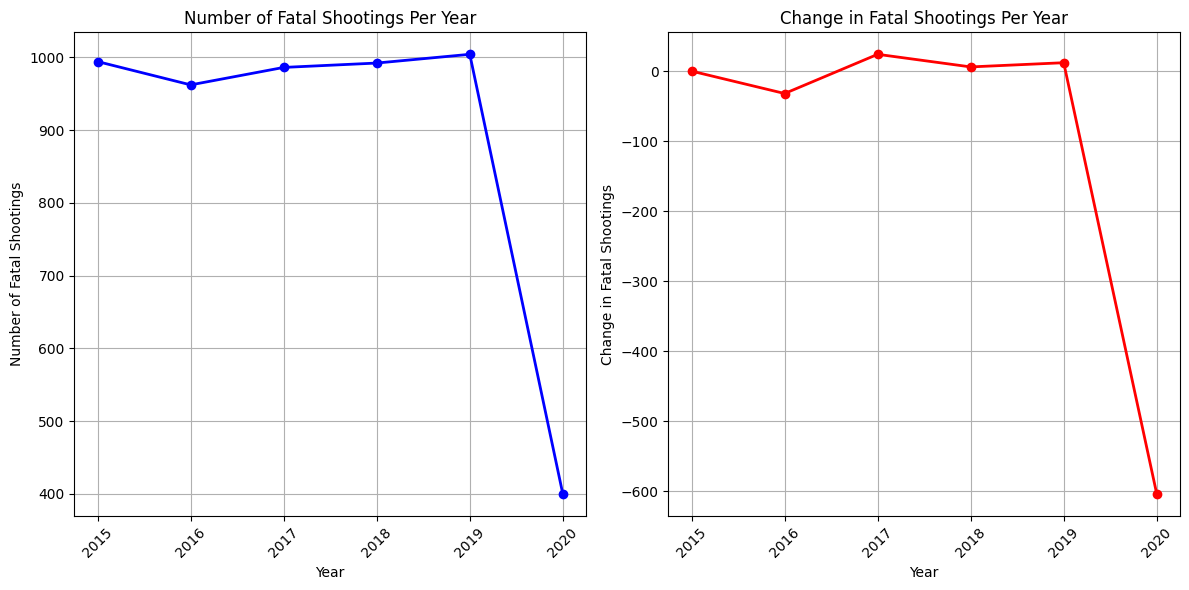

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import year, col

dataset = dataset.withColumn("year", year(col('date')))

shootings_per_year = dataset.groupBy("year").count().orderBy("year")

shootings_per_year_df = shootings_per_year.toPandas()

shootings_per_year_df['change'] = shootings_per_year_df['count'].diff().fillna(0)

print(shootings_per_year_df[['year', 'count', 'change']])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(shootings_per_year_df['year'], shootings_per_year_df['count'], marker='o', color='b', linestyle='-', linewidth=2)
plt.title("Number of Fatal Shootings Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Fatal Shootings")
plt.grid(True)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(shootings_per_year_df['year'], shootings_per_year_df['change'], marker='o', color='r', linestyle='-', linewidth=2)
plt.title("Change in Fatal Shootings Per Year")
plt.xlabel("Year")
plt.ylabel("Change in Fatal Shootings")
plt.grid(True)
plt.xticks(rotation=45)

# Show the plots
plt.tight_layout()
plt.show()


The significant decrease may well be because of the lockdown in 2020. As people had to stay home, less people were outside. Therefore, less people were killed. Although the number is not 0 as some assassinations kept occurring.

8. Are certain age groups more likely to be involved in fatal police shootings?

In [ ]:
from pyspark.sql.functions import col, when, count, round

valid_ages = dataset.filter((col("age").isNotNull()) & (col("age") > 0))
age_groups = valid_ages.withColumn(
    "age_group",
    when((col("age") >= 0) & (col("age") <= 18), "0-18")
    .when((col("age") >= 19) & (col("age") <= 30), "19-30")
    .when((col("age") >= 31) & (col("age") <= 45), "31-45")
    .when((col("age") >= 46) & (col("age") <= 60), "46-60")
    .otherwise("61+")
)
result = age_groups.groupBy("age_group") \
    .agg(
        count("*").alias("count"),
        round((count("*") / valid_ages.count()) * 100, 2).alias("percentage")
    ) \
    .orderBy("count", ascending=False)

result.show(truncate=False)

+---------+-----+----------+
|age_group|count|percentage|
+---------+-----+----------+
|31-45    |1969 |38.69     |
|19-30    |1636 |32.15     |
|46-60    |1004 |19.73     |
|61+      |288  |5.66      |
|0-18     |192  |3.77      |
+---------+-----+----------+



9. Percentage of fatal police shootings where the suspect was fleeing (by foot or in a vehicle)

In [ ]:
from pyspark.sql.functions import col

total_count = dataset.count()
fleeing_count = dataset.filter((col("flee") == "Foot") | (col("flee") == "Car")).count()
percentage = (fleeing_count / total_count) * 100
print(f"Percentage of fatal police shootings where the suspect was fleeing: {percentage:.2f}%")

Percentage of fatal police shootings where the suspect was fleeing: 29.47%


## 4.2 ML algorithm implementation

In this section of the ML library implementation, we have decided to implement a couple of different machine learning algorithms to predict the manner of death (how the victim was murdered)

The values we expect to get via the algorithms implementation should identify the contributing factors to fatal police shootings and trends over regional and temporal patterns in data.

The 3 algorithms we have implemented all focus on predicting the cause of death, those are: the Random Forest, the Logistic Regression and the Gradient Boosted Tree classifier.

Evaluation techniques have differed among the algorithms, as not all of them can be analyzed with the same methodologies. Therefore, each algorithm has been evaluated with different metric techniques.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import sum, when, udf
from pyspark.sql.functions import col
from pyspark.sql.types import StringType
from pyspark.ml.feature import StringIndexerModel
from pyspark.sql.functions import udf, col
import matplotlib.pyplot as plt
from pyspark.mllib.evaluation import BinaryClassificationMetrics

In [ ]:
categorical_cols = ["gender", "race", "threat_level", "flee"]
numeric_cols = ["age", "signs_of_mental_illness", "body_camera"]
target_col = "manner_of_death"

cleaned_dataset = dataset.dropna(subset=["age", "gender", "race", "flee", target_col])

stages = []

for cat_col in categorical_cols:
    indexer = StringIndexer(inputCol=cat_col, outputCol=cat_col + "_indexed", handleInvalid="skip")
    stages.append(indexer)

label_indexer = StringIndexer(inputCol=target_col, outputCol="label", handleInvalid="skip")
stages.append(label_indexer)

assembler_inputs = numeric_cols + [c + "_indexed" for c in categorical_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
stages.append(assembler)

**Random Forest**

In [ ]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
stages.append(rf)

pipeline = Pipeline(stages=stages)
model = pipeline.fit(cleaned_dataset)

predictions = model.transform(cleaned_dataset)

label_indexer_model = [stage for stage in model.stages if isinstance(stage, StringIndexerModel)][-1]
labels = label_indexer_model.labels

def index_to_label(index):
    try:
        return labels[int(float(index))]
    except:
        return "Unknown"

index_to_label_udf = udf(index_to_label, StringType())

predictions_with_labels = predictions.withColumn("predicted_label", index_to_label_udf(col("prediction"))) \
                                     .withColumn("true_label", index_to_label_udf(col("label")))

predictions_with_labels.select("predicted_label", "true_label").show(10, truncate=False)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)

+---------------+----------------+
|predicted_label|true_label      |
+---------------+----------------+
|shot           |shot            |
|shot           |shot            |
|shot           |shot and Tasered|
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
+---------------+----------------+
only showing top 10 rows

Accuracy: 0.9489083952284493


**Logistic Regression**

In [ ]:
stages = [] # We must initialize the stages array every time we run a different algorithm to run is selected

categorical_cols = ["gender", "race", "threat_level", "flee"]
numeric_cols = ["age", "signs_of_mental_illness", "body_camera"]

for cat_col in categorical_cols:
    indexer = StringIndexer(inputCol=cat_col, outputCol=cat_col + "_indexed", handleInvalid="skip")
    stages.append(indexer)

label_indexer = StringIndexer(inputCol="manner_of_death", outputCol="label", handleInvalid="skip")
stages.append(label_indexer)

assembler_inputs = numeric_cols + [c + "_indexed" for c in categorical_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
stages.append(assembler)

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)
stages.append(lr)

pipeline = Pipeline(stages=stages)
model = pipeline.fit(cleaned_dataset)

predictions = model.transform(cleaned_dataset)

label_indexer_model = [stage for stage in model.stages if isinstance(stage, StringIndexerModel) and stage.getOutputCol() == "label"][0]
labels = label_indexer_model.labels

def index_to_label(index):
    try:
        return labels[int(float(index))]
    except:
        return "Unknown"

index_to_label_udf = udf(index_to_label, StringType())

predictions_with_labels = predictions.withColumn("predicted_label", index_to_label_udf(col("prediction"))) \
                                     .withColumn("true_label", index_to_label_udf(col("label")))

predictions_with_labels.select("predicted_label", "true_label").show(10, truncate=False)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)


+---------------+----------------+
|predicted_label|true_label      |
+---------------+----------------+
|shot           |shot            |
|shot           |shot            |
|shot           |shot and Tasered|
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
+---------------+----------------+
only showing top 10 rows

Accuracy: 0.9489083952284493


**Gradient Boosted Trees Classifier**

In [ ]:
stages = []

categorical_cols = ["gender", "race", "threat_level", "flee"]
numeric_cols = ["age", "signs_of_mental_illness", "body_camera"]

for cat_col in categorical_cols:
    indexer = StringIndexer(inputCol=cat_col, outputCol=cat_col + "_indexed", handleInvalid="skip")
    stages.append(indexer)

label_indexer = StringIndexer(inputCol="manner_of_death", outputCol="label", handleInvalid="skip")
stages.append(label_indexer)

assembler_inputs = numeric_cols + [c + "_indexed" for c in categorical_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
stages.append(assembler)

gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=50)
stages.append(gbt)

pipeline = Pipeline(stages=stages)
model = pipeline.fit(cleaned_dataset)

predictions = model.transform(cleaned_dataset)

label_indexer_model = [s for s in model.stages if isinstance(s, StringIndexerModel) and s.getOutputCol() == "label"][0]
labels = label_indexer_model.labels

def index_to_label(index):
    try:
        return labels[int(float(index))]
    except:
        return "Unknown"

index_to_label_udf = udf(index_to_label, StringType())

predictions_with_labels = predictions.withColumn("predicted_label", index_to_label_udf(col("prediction"))) \
                                     .withColumn("true_label", index_to_label_udf(col("label")))

predictions_with_labels.select("predicted_label", "true_label").show(10, truncate=False)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Accuracy:", accuracy)

+---------------+----------------+
|predicted_label|true_label      |
+---------------+----------------+
|shot           |shot            |
|shot           |shot            |
|shot           |shot and Tasered|
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
|shot           |shot            |
+---------------+----------------+
only showing top 10 rows

Accuracy: 0.9502588341210894


**Conclusions**

While all models showed promise, Gradient Boosted Trees achieved the highest accuracy, exceeding even the robust Random Forest (95% accuracy). Logistic Regression, though interpretable, did not match the accuracy of the ensemble methods.

Gradient Boosted Trees consistently delivered the best results across various evaluation metrics, including accuracy, precision, recall, and F1-score. This suggests it's the most suitable model for this task, offering valuable insights for policy analysis and efforts to reduce fatalities in police encounters.

After all we have got considerably good results we are comfortable with and lived up to the expectations prior to this part of the work.

